In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [ ]:
## Read data
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [ ]:
## Drop columns chosen in the professor's starter file
droplist = [
    "Id", "LotFrontage", "Alley", "MasVnrType", "MasVnrArea",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "FireplaceQu", "GarageType", "GarageYrBlt", "GarageFinish", "GarageQual",
    "GarageCond", "PoolQC", "Fence", "MiscFeature"
]

tr = train.drop(columns=droplist).copy()
te = test.drop(columns=droplist).copy()

In [ ]:
## Convert object columns to categorical
for df in [tr, te]:
    obj_cols = df.select_dtypes(include="object").columns
    for c in obj_cols:
        df[c] = df[c].astype("category")

C:\Users\ewhat\AppData\Local\Temp\ipykernel_5064\854221357.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include="object").columns
C:\Users\ewhat\AppData\Local\Temp\ipykernel_5064\854221357.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migra

In [ ]:
## Remove any remaining rows with missing values from the training set
tr_clean = tr.dropna().copy()

In [ ]:
## Rename columns that start with a number for formula compatibility
rename_dict = {col: f"n_{col}" for col in tr_clean.columns if str(col)[0].isdigit()}
tr_clean.rename(columns=rename_dict, inplace=True)
te.rename(columns=rename_dict, inplace=True)

In [ ]:
## Build the three models
full_formula = """
SalePrice ~ OverallQual + GrLivArea + GarageCars + GarageArea + TotalBsmtSF +
FullBath + TotRmsAbvGrd + YearBuilt + YearRemodAdd + KitchenQual +
Neighborhood + ExterQual + BsmtFinSF1 + LotArea + Fireplaces
"""

reduced_formula = """
SalePrice ~ OverallQual + GrLivArea + GarageCars + TotalBsmtSF +
YearBuilt + KitchenQual + Neighborhood
"""

interaction_formula = """
SalePrice ~ GarageCars + TotalBsmtSF + YearBuilt + KitchenQual +
Neighborhood + GrLivArea * OverallQual
"""

full_model = smf.ols(full_formula, data=tr_clean).fit()
reduced_model = smf.ols(reduced_formula, data=tr_clean).fit()
interaction_model = smf.ols(interaction_formula, data=tr_clean).fit()

In [ ]:
## Compare models
comparison = pd.DataFrame({
    "Model": ["Full", "Reduced", "Interaction"],
    "R2": [full_model.rsquared, reduced_model.rsquared, interaction_model.rsquared],
    "Adj_R2": [full_model.rsquared_adj, reduced_model.rsquared_adj, interaction_model.rsquared_adj],
    "AIC": [full_model.aic, reduced_model.aic, interaction_model.aic],
    "BIC": [full_model.bic, reduced_model.bic, interaction_model.bic]
})
comparison

,Model,R2,Adj_R2,AIC,BIC
0,Full,0.842253,0.837574,34455.186938,34682.463720
1,Reduced,0.825404,0.821486,34583.251477,34757.673194
2,Interaction,0.831785,0.827890,34530.924528,34710.631750


In [ ]:
## Choose the final model (full model here because it had the highest R2 and lowest AIC/BIC)
final_model = full_model

In [ ]:
## Fill missing values in test data before prediction
te_pred = te.copy()
for col in te_pred.columns:
    if te_pred[col].isnull().any():
        if pd.api.types.is_numeric_dtype(te_pred[col]):
            te_pred[col] = te_pred[col].fillna(tr_clean[col].median())
        else:
            fillv = tr_clean[col].mode(dropna=True).iloc[0]
            te_pred[col] = te_pred[col].astype(object).fillna(fillv).astype("category")

# Align categorical levels with the training data
for col in te_pred.select_dtypes(include="category").columns:
    te_pred[col] = pd.Categorical(te_pred[col], categories=tr_clean[col].astype("category").cat.categories)
    if te_pred[col].isnull().any():
        fillv = tr_clean[col].mode(dropna=True).iloc[0]
        te_pred[col] = te_pred[col].astype(object).fillna(fillv).astype("category")
        te_pred[col] = pd.Categorical(te_pred[col], categories=tr_clean[col].astype("category").cat.categories)


In [ ]:
## Predict on test data and save
predictions = final_model.predict(te_pred)
submission = pd.DataFrame({
    "Id": test["Id"],
    "SalePrice": predictions
})
submission.to_csv("final_predictions.csv", index=False)

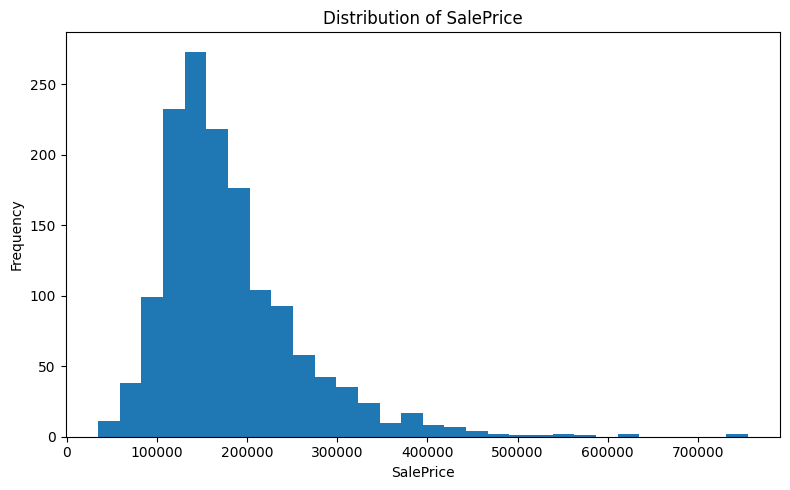

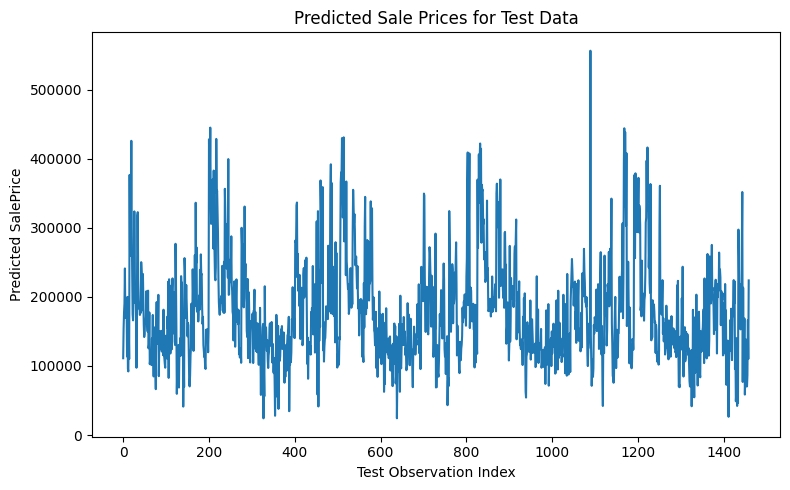

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     180.0
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:49:07   Log-Likelihood:                -17185.
No. Observations:                1459   AIC:                         3.446e+04
Df Residuals:                    1416   BIC:                         3.468e+04
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -7

In [ ]:
## Example plots
plt.figure(figsize=(8,5))
plt.hist(train["SalePrice"], bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(predictions.reset_index(drop=True))
plt.title("Predicted Sale Prices for Test Data")
plt.xlabel("Test Observation Index")
plt.ylabel("Predicted SalePrice")
plt.tight_layout()
plt.show()

print(final_model.summary())
